1040
        datetime  value
0     2021-01-01  0.762
1     2021-01-02  1.129
2     2021-01-03  0.647
3     2021-01-04  0.051
4     2021-01-05  0.017
...          ...    ...
1457  2024-12-28  0.165
1458  2024-12-29  0.076
1459  2024-12-30  0.026
1460  2024-12-31  1.568
1461  2025-01-01  8.078

[1462 rows x 2 columns]


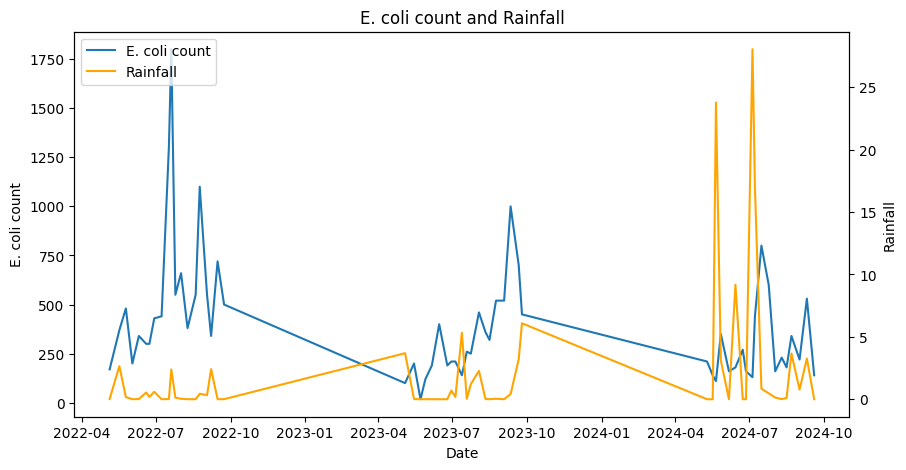

In [52]:
from matplotlib import pyplot as plt
from pandas.core.interchange.dataframe_protocol import DataFrame

import app
import pandas as pd
import geopandas as gpd


ecoli_timeseries_dfs = app.get_ecoli_datasets()
wolvercote_ecoli_timeseries = ecoli_timeseries_dfs[("11946", "ea_bathing_water")]

# get site info for Wolvercote
wolvercote_site_id = "11946"
ecoli_data_set_wolvercote = "ea_bathing_water"
df_ea_bathing_water_site = app.get_sites_for_dataset_as_pandas("ea_bathing_water")
gdf_ea_bathing_water_site = gpd.GeoDataFrame(df_ea_bathing_water_site)
wolvercote_coordinates = gdf_ea_bathing_water_site[gdf_ea_bathing_water_site["properties.id"]==wolvercote_site_id]["geometry.coordinates"]

# get rainfall sites
df_sites_rainfall = app.get_sites_for_dataset_as_pandas("rainfall", display=False)
gdf_sites_rainfall = gpd.GeoDataFrame(df_sites_rainfall)
print(gdf_sites_rainfall.size)

# find rainfall sites near Wolvercote
from geopy.distance import geodesic
sites_close_to_wolvercote = []
max_distance_km = 8 # 8km
for idx, rainfall_site in gdf_sites_rainfall.iterrows():
    distance_in_km = geodesic(rainfall_site.loc["geometry.coordinates"], wolvercote_coordinates).km
    if distance_in_km < max_distance_km:
            sites_close_to_wolvercote.append(rainfall_site)
# print(sites_close_to_wolvercote) # gives ids ["39008", "39034", "39140"]

# just to experiment, take the rainfall data from "39008", Thames at Eynsham
rainfall_timeseries_rainfall_eynsham = app.get_timeseries_for_dataset_and_site_as_pandas("39008", "rainfall")
print(rainfall_timeseries_rainfall_eynsham)

# helper functions
def convert_datetime_to_date_with_resampling(df: pd.DataFrame):
    new_df = df
    new_df["date"] = pd.to_datetime(new_df["datetime"].transform(lambda datetime: datetime.date()))
    new_df.set_index('date')
    new_df = new_df.resample('D').mean().dropna()
    return new_df

def merge_on_date(df1: pd.DataFrame, df2: pd.DataFrame):
    merged = df1
    merged.merge(df2, on='date', how='left').dropna()
    return merged

def plot_values_vs_date(merged: pd.DataFrame, x: str, y1: str, y2: str, xlabel: str, y1label: str, y2label: str):
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(merged[x], merged[y1], label=y1label)
    ax1.set_ylabel(y1label)
    ax2 = ax1.twinx()
    ax2.plot(merged[x], merged[y2], color='orange', label=y2label)
    ax2.set_ylabel(y2label)
    plt.title("")
    ax1.set_xlabel(xlabel)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    plt.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    plt.show()


# first make datetimes just into dates
wolvercote_ecoli_timeseries["datetime"] = pd.to_datetime(wolvercote_ecoli_timeseries["datetime"].transform(lambda datetime: datetime.date()))
rainfall_timeseries_rainfall_eynsham['datetime'] = pd.to_datetime(rainfall_timeseries_rainfall_eynsham['datetime'])
rainfall_timeseries_rainfall_eynsham = rainfall_timeseries_rainfall_eynsham.set_index('datetime')
rainfall_timeseries_rainfall_eynsham_resammpled = rainfall_timeseries_rainfall_eynsham.resample('D').mean().dropna()
wolvercote_ecoli_and_eynsham_rainfall = wolvercote_ecoli_timeseries.merge(rainfall_timeseries_rainfall_eynsham_resammpled, on='datetime', how='left').dropna()

fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(wolvercote_ecoli_and_eynsham_rainfall['datetime'], wolvercote_ecoli_and_eynsham_rainfall['escherichia coli count'], label='E. coli count')
ax1.set_ylabel('E. coli count')
ax2 = ax1.twinx()
ax2.plot(wolvercote_ecoli_and_eynsham_rainfall['datetime'], wolvercote_ecoli_and_eynsham_rainfall['value'], color='orange', label='Rainfall')
ax2.set_ylabel('Rainfall')
plt.title("E. coli count and Rainfall")
ax1.set_xlabel("Date")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()


In [13]:
#extract all site details and convert to GeoDataFrames
max_distance = 0.075 # e.g., within 0.075 degrees (~8 km)
no_keep = 3 #number of nearby sites to keep for each dataset

print(gdf_sites_rainfall)



        type geometry.type  geometry.coordinates  properties.id  \
0    Feature         Point  [-0.30771, 51.41544]          39001   
1    Feature         Point  [-1.17947, 51.63852]          39002   
2    Feature         Point  [-0.18134, 51.41976]          39003   
3    Feature         Point  [-0.13899, 51.37359]          39004   
4    Feature         Point  [-0.25195, 51.43167]          39005   
..       ...           ...                   ...            ...   
125  Feature         Point  [-0.39784, 51.54879]          39145   
126  Feature         Point  [-1.23396, 51.57471]          39146   
127  Feature         Point  [-0.74212, 51.76664]          39147   
128  Feature         Point  [-0.70211, 51.52415]          39148   
129  Feature         Point  [-0.69747, 51.52923]          39866   

                              properties.name    properties.river  \
0                          Thames at Kingston              Thames   
1                         Thames at Days Weir            